# Creation and visualization of quadrilateral shapes

This notebook walks through the three quadrilateral primitives in
`metashapes.shape.primitives.quads`: **`Rectangle`**, **`ConvexQuad`**, and
**`IsoscelesTrapezoid`**. For each one we:

1. construct it with a few interesting parameters,
2. evaluate its signed distance function (SDF) on a grid,
3. turn that SDF into a binary mask,
4. convert the same shape to a Shapely polygon and rasterize *that*, and
5. compare the two masks to see they agree almost everywhere.

This notebook only covers **creating and inspecting** shapes -- no gradients,
no optimization. Optimizing shape parameters against a target has its own,
separate example notebook.

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from metashapes.shape import Rectangle, ConvexQuad, IsoscelesTrapezoid
from metashapes.lattice.basis import Lattice
from metashapes.lattice.unit_cell import UnitCell
from metashapes.adapters.shapely.dispatch import shape_to_shapely
from metashapes.adapters.shapely.raster import shapely_to_numpy

dtype = torch.float32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Shapes live in a `UnitCell`

A `Shape` on its own lives in infinite, continuous space -- it knows nothing
about periodicity. A `UnitCell` pairs a `Shape` (the "scene") with a
`Lattice`, and turns the shape's SDF into a *periodic* SDF by taking the
minimum over neighboring lattice copies. `UnitCell.mask()` and
`UnitCell.rasterize()` sample that periodic field on a grid, which is the
representation the rest of this library (analysis, generators, GDS export)
works with.

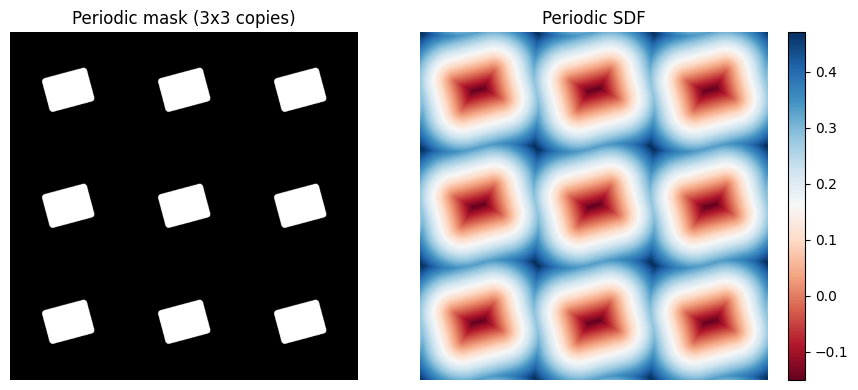

In [21]:
lattice = Lattice.rectangular(1.0, 1.0).to(dtype=dtype, device=device)

demo = Rectangle(center=[0.5, 0.5], size=[0.4, 0.3], angle=15.0, corner_radius=0.03)
demo = demo.to(dtype=dtype, device=device)
demo_cell = UnitCell(lattice=lattice, scene=demo)

nx = ny = 256
mask = demo_cell.mask(nx, ny, cartesian=True, repeat=(3, 3))
sdf_periodic = demo_cell.rasterize(nx, ny, cartesian=True, repeat=(3, 3))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mask.cpu().detach(), origin='lower', cmap='gray')
axes[0].set_title('Periodic mask (3x3 copies)')
im = axes[1].imshow(sdf_periodic.cpu().detach(), origin='lower', cmap='RdBu')
axes[1].set_title('Periodic SDF')
plt.colorbar(im, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.axis('off')
fig.tight_layout()
plt.show()

## Inspecting a single shape: SDF, mask, and Shapely agreement

The rest of this notebook looks at each primitive **on its own** -- not
through a `UnitCell` -- so we can compare its SDF-derived mask directly
against its Shapely conversion. `shape_to_shapely()` converts a single
shape's own geometry; it has no notion of periodic copies, so comparing it
against a *periodic* mask wouldn't be a fair comparison.

`show_shape()` below is a small helper used identically for all three
primitives: it builds a grid sized from the shape's own `bounds()` (so you
never need to hand-pick a viewport), evaluates the SDF, derives a hard mask
from its sign, rasterizes the Shapely conversion on the *same* grid, and
plots all four side by side. The two masks won't agree at literally every
pixel -- the SDF and Shapely rasterize a curved or rounded boundary very
slightly differently -- but the agreement should be well above 99%; a much
lower number would mean something is actually wrong.

In [22]:
def show_shape(shape, title=None, n=400, pad=0.25):
    """Plot a shape's SDF, the hard mask derived from it, the mask from its
    Shapely conversion, and where the two masks disagree.

    The grid is sized from `shape.bounds()` (plus `pad` on each side), so
    this works for any shape without hand-picking a viewport per call.
    """
    (xmin, ymin), (xmax, ymax) = shape.bounds()
    xmin, xmax = xmin - pad, xmax + pad
    ymin, ymax = ymin - pad, ymax + pad

    xs = torch.linspace(xmin, xmax, n, dtype=dtype, device=device)
    ys = torch.linspace(ymin, ymax, n, dtype=dtype, device=device)
    X, Y = torch.meshgrid(xs, ys, indexing="xy")

    sdf = shape.sdf(X, Y).detach().cpu().numpy()
    mask_sdf = sdf <= 0.0

    geom = shape_to_shapely(shape)
    Xn, Yn = X.detach().cpu().numpy(), Y.detach().cpu().numpy()
    mask_shapely = shapely_to_numpy(geom, Xn, Yn)

    mismatch = mask_sdf != mask_shapely
    agreement = 100.0 * (1.0 - mismatch.mean())

    extent = [xmin, xmax, ymin, ymax]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    im0 = axes[0].imshow(sdf, origin="lower", extent=extent, cmap="RdBu")
    axes[0].contour(Xn, Yn, sdf, levels=[0.0], colors="k", linewidths=1.2)
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    axes[0].set_title("SDF")

    axes[1].imshow(mask_sdf, origin="lower", extent=extent, cmap="gray")
    axes[1].set_title("Mask from SDF\n(sdf <= 0)")

    axes[2].imshow(mask_shapely, origin="lower", extent=extent, cmap="gray")
    axes[2].set_title("Mask from Shapely")

    axes[3].imshow(mismatch, origin="lower", extent=extent, cmap="Reds")
    axes[3].set_title(f"Mismatch\n({agreement:.3f}% agree)")

    for ax in axes:
        ax.set_aspect("equal")
        ax.axis("off")

    fig.suptitle(title or type(shape).__name__, fontsize=14, y=1.03)
    fig.tight_layout()
    plt.show()

    print(f"{title or type(shape).__name__}: mask/Shapely agreement = {agreement:.3f}% "
          f"({mismatch.sum()} / {mismatch.size} pixels differ)")

## `Rectangle`

Parameters: `center`, `size` (width, height), `angle` (degrees), and
`corner_radius` (0 = sharp corners). The example below combines rotation
*and* rounded corners so both features are visible at once.

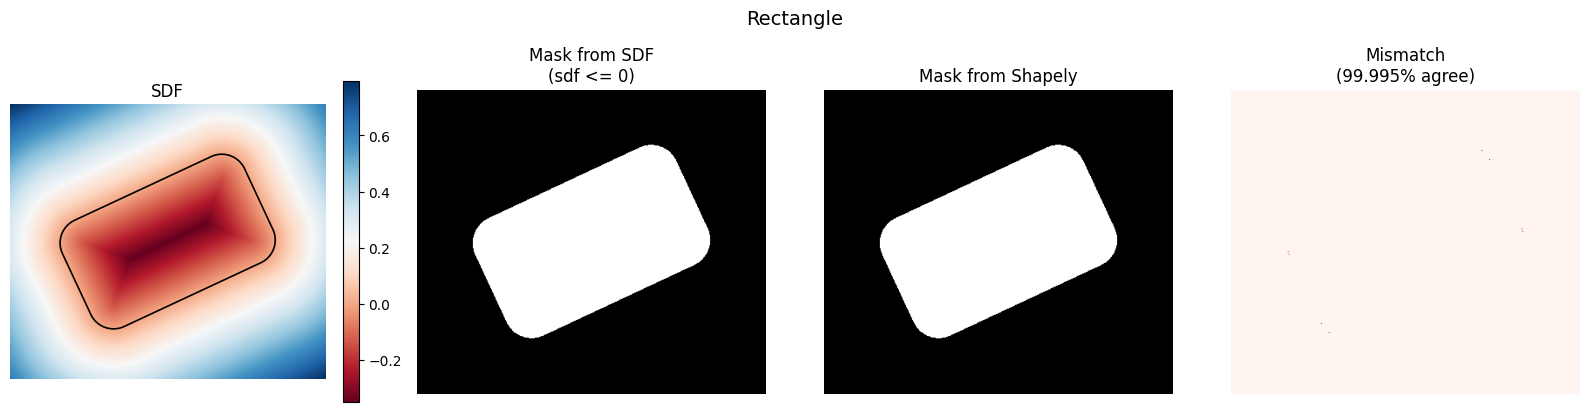

Rectangle: mask/Shapely agreement = 99.995% (8 / 160000 pixels differ)


In [23]:
rect = Rectangle(
    center=[0.0, 0.0],
    size=[1.2, 0.7],
    angle=25.0,
    corner_radius=0.15,
)
rect = rect.to(dtype=dtype, device=device)
show_shape(rect, title="Rectangle")

## `ConvexQuad`

A more general shape than `Rectangle`: it's built from a center and two
frame vectors `u`, `v` (placing corners at combinations of ±u and ±v), with
`alpha`/`beta` stretching the far corner along each direction. With
`alpha = beta = 0` and orthogonal `u`/`v` it reduces to a rectangle; the
example below uses a non-orthogonal `u`/`v` (a sheared parallelogram) and
nonzero `alpha`/`beta`, so the result is visibly a general quadrilateral,
not a disguised rectangle.

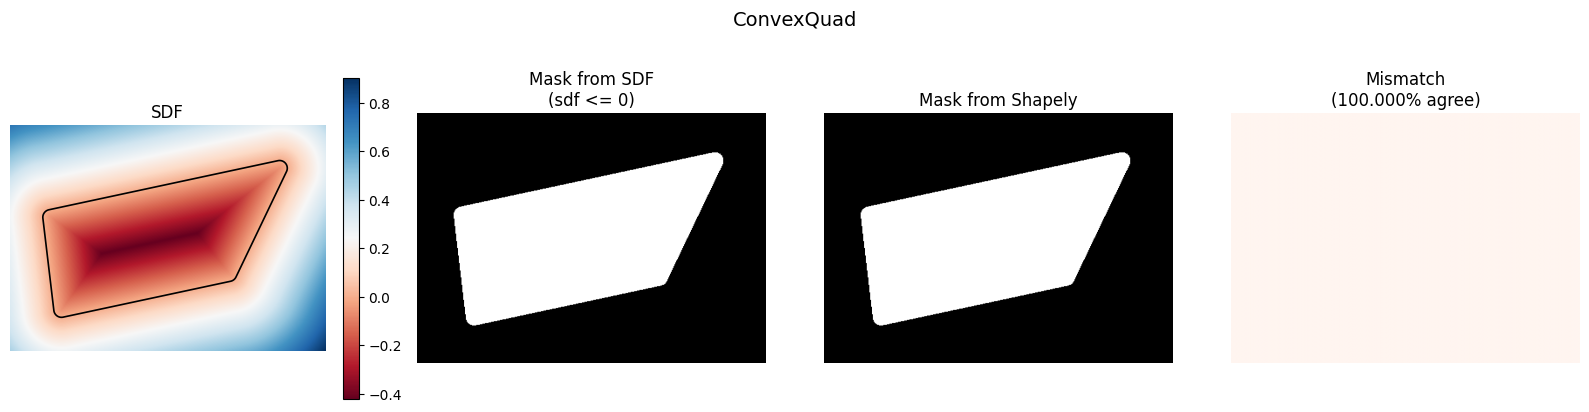

ConvexQuad: mask/Shapely agreement = 100.000% (0 / 160000 pixels differ)


In [24]:
quad = ConvexQuad(
    center=[0.0, 0.0],
    u=[0.7, 0.15],
    v=[0.1, 0.5],
    alpha=0.4,
    beta=-0.2,
    corner_radius=0.06,
)
quad = quad.to(dtype=dtype, device=device)
show_shape(quad, title="ConvexQuad")

## `IsoscelesTrapezoid`

Parameters: `bottom_width`, `top_width`, `height`, `angle`, and
`corner_radius`. The example below uses a top base narrower than the
bottom (`top_width < bottom_width`), a moderate `corner_radius`, and a
slight rotation.

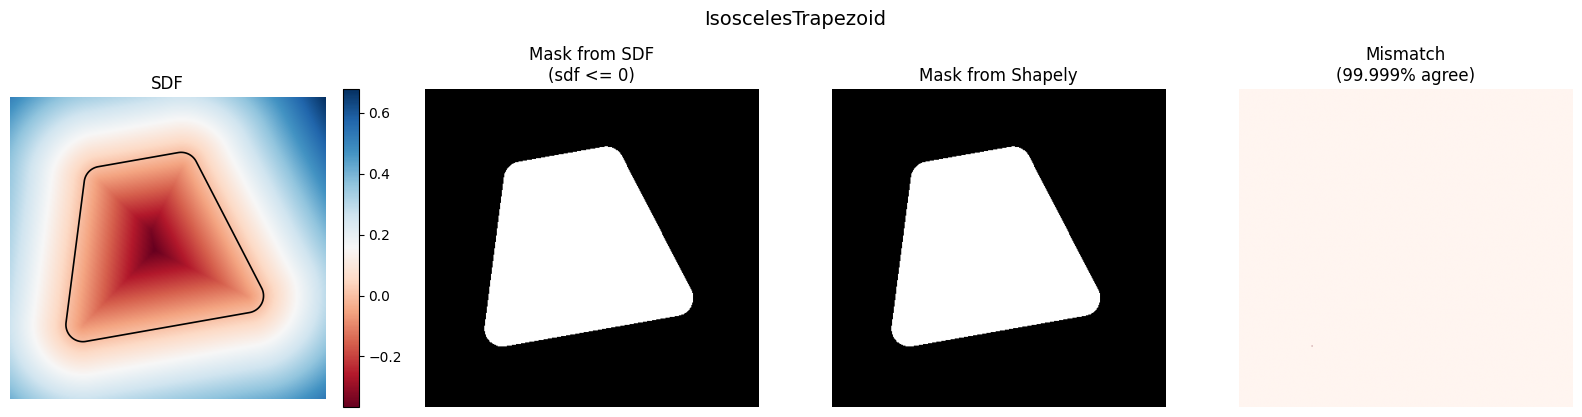

IsoscelesTrapezoid: mask/Shapely agreement = 99.999% (1 / 160000 pixels differ)


In [25]:
trap = IsoscelesTrapezoid(
    center=[0.0, 0.0],
    bottom_width=1.0,
    top_width=0.5,
    height=0.8,
    angle=10.0,
    corner_radius=0.08,
)
trap = trap.to(dtype=dtype, device=device)
show_shape(trap, title="IsoscelesTrapezoid")

## Next steps

This covered creating quadrilateral shapes and inspecting their SDF, mask,
and Shapely representations. For optimizing shape parameters (e.g. against
a target mask or a design objective), see the separate optimization example
notebook.